# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
video_game_data=pd.read_csv('/datasets/games.csv')# Load the dataset

In [3]:
# Display basic information about the dataset
print(video_game_data.head())
print(video_game_data.info())


                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 

In [4]:
# Check for duplicate entries
video_game_data.duplicated().sum()


0

I ran the data head and data info to verify the data and how many pieces of data were in the file. According to the info dump there is 16,715 lines of data. The data types are comprised of floats and objects. 

I then ran duplicated and sum to verify if there are any duplicate entries. There are no duplicate entries. 

in reviewing the data, I noticed that some of the data types are incorrect and need to be changed, like User_score needs to be changed to a float and Year_of_Release needs to be changed to datetime64. I also note that there are missing values in critic_score, User_Score, and Rating. All of which seem to be missing values in the same line.  

### Key Questions to Answer:
- What's the total number of records in our dataset?
- What data types are present in each column?
- Are there any obvious issues with the data?
- Do we see any immediate patterns or anomalies?

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
# Convert column names to lowercase
video_game_data.columns=video_game_data.columns.str.lower()

In [6]:
# Verify the changes
print(video_game_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


### 2.2 Data Type Conversion

In [7]:
# Check current data types
print(video_game_data.dtypes)

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object


In [8]:
# Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.
print("Checking for TBD values:")
for column in video_game_data.columns:
    tbd_count = video_game_data[column].astype(str).str.contains('TBD', case=False, na=False).sum()
    if tbd_count > 0:
        print(f"{column}: {tbd_count} TBD values")

Checking for TBD values:
user_score: 2424 TBD values


In [9]:

# Make changes to data types if necessary
video_game_data['user_score'] = pd.to_numeric(video_game_data['user_score'], errors='coerce')
video_game_data['year_of_release'] = pd.to_numeric(video_game_data['year_of_release'], errors='coerce')
# Describe the columns where the data types have been changed and why.
print(video_game_data.dtypes)


name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
dtype: object


I changed the data types for user_score and year_of_release to correct the issues with the data types. When analyzing the data further down these data types will need to be correct. Otherwise we could run into issues with graphing or plotting the data, or determining averages, or even potentially trends surrounding the age of games over the years. 

this last cell of code was to determine if there was any tbd values. None turned up. However I do know that there are NaN values that are in the dataset. I will have to account for those moving forward. 

### 2.3 Handling Missing Values

In [10]:
# Examine missing values
print("Missing data analysis:")
print(video_game_data.isnull().sum())

# Are older games more likely to have missing scores?
missing_by_year = video_game_data.groupby('year_of_release')['critic_score'].apply(lambda x: x.isnull().sum())


Missing data analysis:
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


In [11]:
# Calculate percentage of missing values
missing_percent=video_game_data.isnull().mean()*100
print(missing_percent)

name                0.011965
platform            0.000000
year_of_release     1.609333
genre               0.011965
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
critic_score       51.319174
user_score         54.591684
rating             40.478612
dtype: float64


In [12]:
# Analyze patterns in missing values
# Missing by row (how many values are missing per record)
video_game_data['missing_count'] = video_game_data.isnull().sum(axis=1)
print(video_game_data['missing_count'].value_counts().sort_index())

# Rows with lots of missing data
problem_rows = video_game_data[video_game_data['missing_count'] >= 3] 

0    6826
1    1819
2    1376
3    6607
4      85
5       2
Name: missing_count, dtype: int64


with this code here I wanted to see how many rows had more than 3 missing values at the same time. While this does not tell us which specific rows and or what the missing values are in each set we do see that there is a recognizable pattern to missing values. Now I must identify what those might equate to. My initial though is it has something to do with the age of the game or the platform they were relased on.

In [13]:

# Create a cleaner version with better column names
missing_analysis = video_game_data.groupby('platform').agg({
    'critic_score': lambda x: x.isnull().sum(),
    'user_score': lambda x: x.isnull().sum(), 
    'rating': lambda x: x.isnull().sum()
}).reset_index()

# Add total games per platform
platform_counts = video_game_data['platform'].value_counts()
missing_analysis['total_games'] = missing_analysis['platform'].map(platform_counts)

# Calculate missing percentages
missing_analysis['critic_missing_pct'] = (missing_analysis['critic_score'] / missing_analysis['total_games'] * 100).round(1)
missing_analysis['user_missing_pct'] = (missing_analysis['user_score'] / missing_analysis['total_games'] * 100).round(1)
missing_analysis['rating_missing_pct'] = (missing_analysis['rating'] / missing_analysis['total_games'] * 100).round(1)

# Sort by total games (most popular platforms first) and show ALL platforms
print(missing_analysis.sort_values('total_games', ascending=False))

   platform  critic_score  user_score  rating  total_games  \
16      PS2         863.0       920.0     680         2161   
4        DS        1434.0      1635.0     878         2151   
17      PS3         511.0       454.0     379         1331   
26      Wii         735.0       760.0     318         1320   
28     X360         346.0       296.0     210         1262   
19      PSP         747.0       788.0     665         1209   
15       PS         997.0      1035.0     989         1197   
13       PC         259.0       204.0     200          974   
29       XB          99.0       238.0      91          824   
6       GBA         384.0       567.0     300          822   
7        GC         108.0       190.0      87          556   
2       3DS         352.0       346.0     292          520   
20      PSV         310.0       287.0     279          430   
18      PS4         140.0       135.0     137          392   
10      N64         319.0       319.0     319          319   
30     X

I wanted to see here if I could notice a pattern between which platforms had more NaN or missing values. Of those I wanted to see if it was older platforms like SNES or NES. What I ended up also noticing is that while the percentages are higher on older platforms and niche platforms the total volume of entries in those does not impact the overall percentages of missing data. Next I want to explore if there is a correlation to year of release for each platform and the number of missing values.

In [14]:
# Extract year from datetime for easier analysis
video_game_data['release_year'] = video_game_data['year_of_release']

# Correct missing values analysis by year using size for true row count
missing_by_year = video_game_data.groupby('release_year').agg(
    total_games=('name', 'size'),
    critic_missing=('critic_score', lambda x: x.isnull().sum()),
    user_missing=('user_score', lambda x: x.isnull().sum()),
    rating_missing=('rating', lambda x: x.isnull().sum())
)

# Calculate missing percentages
missing_by_year['critic_missing_pct'] = (missing_by_year['critic_missing'] / missing_by_year['total_games'] * 100).round(1)
missing_by_year['user_missing_pct'] = (missing_by_year['user_missing'] / missing_by_year['total_games'] * 100).round(1)
missing_by_year['rating_missing_pct'] = (missing_by_year['rating_missing'] / missing_by_year['total_games'] * 100).round(1)

print("Missing values analysis by year:")
print(missing_by_year)

Missing values analysis by year:
              total_games  critic_missing  user_missing  rating_missing  \
release_year                                                              
1980.0                  9             9.0           9.0               9   
1981.0                 46            46.0          46.0              46   
1982.0                 36            36.0          36.0              36   
1983.0                 17            17.0          17.0              17   
1984.0                 14            14.0          14.0              14   
1985.0                 14            13.0          13.0              13   
1986.0                 21            21.0          21.0              21   
1987.0                 16            16.0          16.0              16   
1988.0                 15            14.0          14.0              14   
1989.0                 17            17.0          17.0              17   
1990.0                 16            16.0          16.0            

In [15]:
fresh_data = pd.read_csv('/datasets/games.csv')
video_game_data['year_of_release'] = pd.to_numeric(fresh_data['Year_of_Release'], errors='coerce')

In [16]:
print("First 20 year values:")
print(video_game_data['year_of_release'].head(20))

print("\nData type:")
print(video_game_data['year_of_release'].dtype)

print("\nValue counts for years:")
print(video_game_data['year_of_release'].value_counts().head(10))

First 20 year values:
0     2006.0
1     1985.0
2     2008.0
3     2009.0
4     1996.0
5     1989.0
6     2006.0
7     2006.0
8     2009.0
9     1984.0
10    2005.0
11    2005.0
12    1999.0
13    2007.0
14    2010.0
15    2009.0
16    2013.0
17    2004.0
18    1990.0
19    2005.0
Name: year_of_release, dtype: float64

Data type:
float64

Value counts for years:
2008.0    1427
2009.0    1426
2010.0    1255
2007.0    1197
2011.0    1136
2006.0    1006
2005.0     939
2002.0     829
2003.0     775
2004.0     762
Name: year_of_release, dtype: int64


In [17]:

print("Year data summary:")
print(f"Total records: {len(video_game_data)}")
print(f"Records with valid years: {video_game_data['release_year'].notna().sum()}")
print(f"Records with missing years: {video_game_data['release_year'].isna().sum()}")

# Check what years we actually have
print("\nUnique years in dataset:")
print(sorted(video_game_data['release_year'].dropna().unique()))

Year data summary:
Total records: 16715
Records with valid years: 16446
Records with missing years: 269

Unique years in dataset:
[1980.0, 1981.0, 1982.0, 1983.0, 1984.0, 1985.0, 1986.0, 1987.0, 1988.0, 1989.0, 1990.0, 1991.0, 1992.0, 1993.0, 1994.0, 1995.0, 1996.0, 1997.0, 1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0]


In [18]:
# Let's create a clean analysis of missing data patterns by year
missing_by_year = video_game_data.groupby('year_of_release').agg({
    'critic_score': ['size', lambda x: x.isnull().sum()],
    'user_score': ['size', lambda x: x.isnull().sum()],
    'rating': ['size', lambda x: x.isnull().sum()]
})

# Flatten column names for easier handling
missing_by_year.columns = ['total_games', 'critic_missing', 'total_games2', 'user_missing', 'total_games3', 'rating_missing']
missing_by_year = missing_by_year[['total_games', 'critic_missing', 'user_missing', 'rating_missing']]

# Calculate missing percentages
missing_by_year['critic_missing_pct'] = (missing_by_year['critic_missing'] / missing_by_year['total_games'] * 100).round(1)
missing_by_year['user_missing_pct'] = (missing_by_year['user_missing'] / missing_by_year['total_games'] * 100).round(1)
missing_by_year['rating_missing_pct'] = (missing_by_year['rating_missing'] / missing_by_year['total_games'] * 100).round(1)

print("Missing values analysis by year (with corrected years):")
print(missing_by_year.tail(15))  # Show recent years first

Missing values analysis by year (with corrected years):
                 total_games  critic_missing  user_missing  rating_missing  \
year_of_release                                                              
2002.0                   829           202.0         365.0             174   
2003.0                   775           190.0         259.0             162   
2004.0                   762           201.0         273.0             164   
2005.0                   939           284.0         356.0             233   
2006.0                  1006           386.0         454.0             328   
2007.0                  1197           505.0         568.0             376   
2008.0                  1427           712.0         766.0             446   
2009.0                  1426           775.0         812.0             415   
2010.0                  1255           755.0         788.0             456   
2011.0                  1136           636.0         635.0             433   
2012.0  

what is interesting about this data is it seems that there are actually more missing values in the recent years post 2009, in comparison to pre 2009 where the missing values are lower percentages.

In [19]:

recent_data= video_game_data[(video_game_data['year_of_release']>=2009) & (video_game_data['year_of_release']<=2016)].copy()
print(f'Original Dataset:{len(video_game_data)}games')
print(f'2009-2016 Dataset:{len(recent_data)}games')


Original Dataset:16715games
2009-2016 Dataset:6703games


My belief is that for us to be able to figure out where to focus our budget for next year comes down to what are the current/recent trends? The only way to figure that out is to refine our data to a more recent grouping of years. As you see here, I have refined it to games from 2009-2016. This is only step 1. I will then refine the data further to retain only complete data sets, or data sets that have 2 of the 3 critical reference points in critic_score, user_score, rating. 

In [20]:
# Handle missing values based on analysis
# Your code here to handle missing values according to your strategy
critical_data=['critic_score', 'user_score', 'rating']
recent_data['critical_missing_count']= recent_data[critical_data].isnull().sum(axis=1)

print('Distribution of missing variables per game:')
print(recent_data['critical_missing_count'].value_counts().sort_index())

Distribution of missing variables per game:
0    2688
1     623
2     890
3    2502
Name: critical_missing_count, dtype: int64


In reviewing the missing value distribution, I made a deliberate decsion to remove games missing 2 or mor of the 3 critical data points (critic_score, user_score, an rating). While this reduced the dataset, the resoning is rooted in the business objective that we are trying to identify patterns that determine a game's success and plan an advertising campagin for 2017. Games with out at least 2 of these 3 data points do not give us enough information to make confident recommendations. 

Further noted that it is true the missingness is not random and varies by platform and year, filling in the missing values with means or medians would have artificially inflated or distorted  our results. Inserting data points where none exist would give us false confidence in out conclusions. Even while removing a number of data points we still had a sufficiently large set of data points that spanned over the most recent 8 year period to help identify trends so we can make confident recommendations down the line. 

In [21]:
games_full=recent_data[recent_data['critical_missing_count']==0].copy()
games_miss_1= recent_data[recent_data['critical_missing_count']==1].copy()
games_miss_more= recent_data[recent_data['critical_missing_count']>=2].copy()

print(f'\nGame Data Cleaning Results')
print(f'Games with all data points(keep):{len(games_full)}games')
print(f'Games with 1 missing data point(keep):{len(games_miss_1)} games')
print(f'Games with multiple missing data points(remove):{len(games_miss_more)} games')
print(f'Total games to keep:{len(games_full) + len(games_miss_1)} games')


Game Data Cleaning Results
Games with all data points(keep):2688games
Games with 1 missing data point(keep):623 games
Games with multiple missing data points(remove):3392 games
Total games to keep:3311 games


In [22]:
clean_data=pd.concat([games_full, games_miss_1], ignore_index=True)
print(f'\nFully Cleaned Data for further evaluation :{len(clean_data)} games')



Fully Cleaned Data for further evaluation :3311 games


# Why do you think the values are missing? Give possible reasons.
# Explain why you filled in the missing values as you did or why you decided to leave them blank.

I decided to withold the data. It didnt make sense to try and fill in the missing values with the mean or median numbers. This would have diluted the actual results of the data and skewed our perception of where to focus the budget moving forward. By removing those data points we now have a much better representation of the data and we can go down multiple different avenues to see what drivers could determine where to focus the budget. 

### 2.4 Calculate Total Sales

In [23]:
# Calculate total sales across all regions and put them in a different column
clean_data['total_sales']= (clean_data['na_sales'] + clean_data['eu_sales'] + clean_data['jp_sales'] + clean_data['other_sales'])

print(clean_data.info())
print(clean_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3311 entries, 0 to 3310
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    3311 non-null   object 
 1   platform                3311 non-null   object 
 2   year_of_release         3311 non-null   float64
 3   genre                   3311 non-null   object 
 4   na_sales                3311 non-null   float64
 5   eu_sales                3311 non-null   float64
 6   jp_sales                3311 non-null   float64
 7   other_sales             3311 non-null   float64
 8   critic_score            2957 non-null   float64
 9   user_score              3102 non-null   float64
 10  rating                  3251 non-null   object 
 11  missing_count           3311 non-null   int64  
 12  release_year            3311 non-null   float64
 13  critical_missing_count  3311 non-null   int64  
 14  total_sales             3311 non-null   

# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [24]:
# Create a DataFrame with game releases by year
clean_data_release_years = clean_data.drop(columns=['missing_count', 'critical_missing_count','year_of_release','platform','genre','critic_score','user_score','rating'])

                                         
print(clean_data_release_years.head())

                        name  na_sales  eu_sales  jp_sales  other_sales  \
0          Wii Sports Resort     15.61     10.93      3.28         2.95   
1  New Super Mario Bros. Wii     14.44      6.94      4.70         2.24   
2         Kinect Adventures!     15.00      4.89      0.24         1.69   
3               Wii Fit Plus      9.01      8.49      2.53         1.77   
4         Grand Theft Auto V      7.02      9.09      0.98         3.96   

   release_year  total_sales  
0        2009.0        32.77  
1        2009.0        28.32  
2        2010.0        21.82  
3        2009.0        21.80  
4        2013.0        21.05  


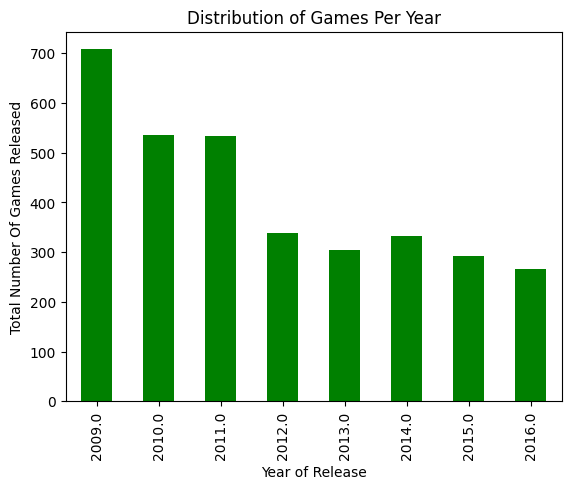

<Figure size 1200x600 with 0 Axes>

In [25]:
# Visualize the distribution of games across years

yearly_dist= clean_data_release_years['release_year'].value_counts().sort_index()

yearly_dist.plot(kind='bar', color='green')
plt.title('Distribution of Games Per Year')
plt.xlabel('Year of Release')
plt.ylabel('Total Number Of Games Released')
plt.figure(figsize=(12,6))
plt.show()


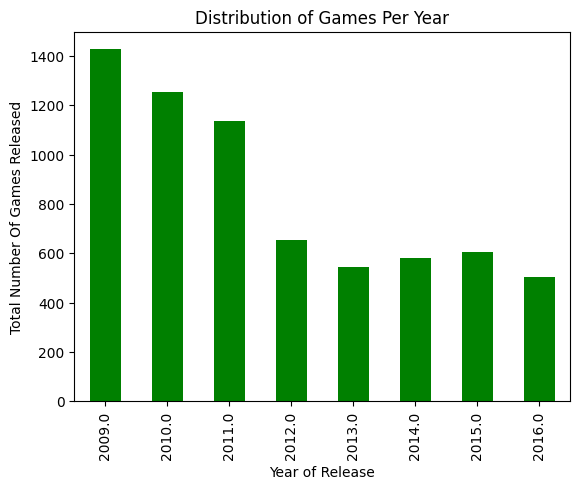

<Figure size 1200x600 with 0 Axes>

In [26]:
#comparison plot to show how many games were actually released between 2009 and 2016. 
total_yearly_dist= recent_data['release_year'].value_counts().sort_index()

total_yearly_dist.plot(kind='bar', color='green')
plt.title('Distribution of Games Per Year')
plt.xlabel('Year of Release')
plt.ylabel('Total Number Of Games Released')
plt.figure(figsize=(12,6))
plt.show()


In [27]:
# Display summary statistics for each year
yearly_sales_stats=clean_data_release_years.groupby('release_year')['total_sales'].agg(['mean', 'median']).round(2)
yearly_critic_stats=clean_data.groupby('release_year')['critic_score'].agg(['mean', 'median']).round(2)
yearly_user_stats=clean_data.groupby('release_year')['user_score'].agg(['mean', 'median']).round(2)

print(f'Yearly Sales Stats:')
print(yearly_sales_stats)
print()
print(f'Yearly Critic Score Analysis:')
print(yearly_critic_stats)
print()
print(f'Yearly User Score Analysis')
print(yearly_user_stats)

Yearly Sales Stats:
              mean  median
release_year              
2009.0        0.71    0.28
2010.0        0.83    0.33
2011.0        0.75    0.28
2012.0        0.89    0.40
2013.0        0.93    0.38
2014.0        0.74    0.30
2015.0        0.62    0.20
2016.0        0.36    0.11

Yearly Critic Score Analysis:
               mean  median
release_year               
2009.0        67.58    69.0
2010.0        67.46    70.0
2011.0        68.69    70.0
2012.0        72.98    75.0
2013.0        71.28    75.0
2014.0        71.07    73.0
2015.0        73.06    74.0
2016.0        73.16    74.5

Yearly User Score Analysis
              mean  median
release_year              
2009.0        6.99     7.3
2010.0        6.88     7.2
2011.0        6.63     7.0
2012.0        6.82     7.1
2013.0        6.47     6.8
2014.0        6.57     7.0
2015.0        6.67     7.1
2016.0        6.63     7.0


When reviewing this data I needed to make a slight adjustment. Really only to figure out the total number of games released per year. With my cleaned data that number was skewed. As my data removes games that do not have at least 2 of the 3 critical data points. When looking at the data as is, it shows that there are far less games released in later games than older games this is due to missing data points. I decided to run a comparison with the total number of games released between 2009 and 2016 even those missing more than 1 critical data point. While it did not change the overall result being newer games released at a less frequent amount it does show that a significant amount of games are missing from the data pool. What was interesting is not only the total number of games released per year decreased, but so did user score. However Critic score average climbed year over year. Not sure what to make of that but it is interesting. Could it be that users are reviewing games differently because they are viewing it as a pleasure experience and critics are reviewing them with simple key metrics. Without having testimonials from each category it is hard to say. As for the decrease in games released, that makes sense as games evolve the complexity of manufacturing them is more time consuming, as well as user experience being much higher evaluated in todays gaming world vs when games began to come out. 

### Questions to Consider:
- Which years show significant numbers of game releases?
- Are there any notable trends or patterns in the number of releases?
- Is there enough recent data to make predictions for 2017?

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [28]:
# Calculate total sales by platform and year

# Only sum the sales columns, scores should not be summed
platform_sales = clean_data.groupby(['release_year', 'platform'])['total_sales'].sum()

print(f'Sales by Platform Per Year:')
print(platform_sales)

Sales by Platform Per Year:
release_year  platform
2009.0        DS           53.29
              PC           15.90
              PS2          15.00
              PS3         119.72
              PSP          23.80
                           ...  
2016.0        PS4          57.77
              PSV           1.18
              WiiU          3.48
              X360          1.19
              XOne         23.96
Name: total_sales, Length: 68, dtype: float64


In [29]:
# Create a heatmap of platform sales over time-- Please note I have not learned heat maps yet. So I will be representing differently. 
platform_sales_pivot=clean_data.pivot_table(values='total_sales', index='release_year', columns='platform', aggfunc='sum', fill_value=0)
print('Platform sales by year (pivot table):')
print(platform_sales_pivot)

Platform sales by year (pivot table):
platform        3DS     DS     PC    PS2     PS3    PS4    PSP    PSV     Wii  \
release_year                                                                    
2009.0         0.00  53.29  15.90  15.00  119.72   0.00  23.80   0.00  165.90   
2010.0         0.00  30.73  21.76   2.70  129.15   0.00  18.83   0.00   78.25   
2011.0        44.74   7.93  32.58   0.29  136.53   0.00   4.32   3.88   37.21   
2012.0        39.43   1.71  22.32   0.00   95.87   0.00   0.45  13.11   17.11   
2013.0        16.36   0.38  10.98   0.00  103.47  25.07   0.34   6.48    7.97   
2014.0        13.59   0.00  11.85   0.00   35.56  80.95   0.00   6.74    2.57   
2015.0        11.20   0.00   7.38   0.00   10.48  81.16   0.00   2.99    0.00   
2016.0         2.32   0.00   4.89   0.00    1.63  57.77   0.00   1.18    0.00   

platform       WiiU    X360   XOne  
release_year                        
2009.0         0.00  112.56   0.00  
2010.0         0.00  161.44   0.00  
201

<Figure size 1400x800 with 0 Axes>

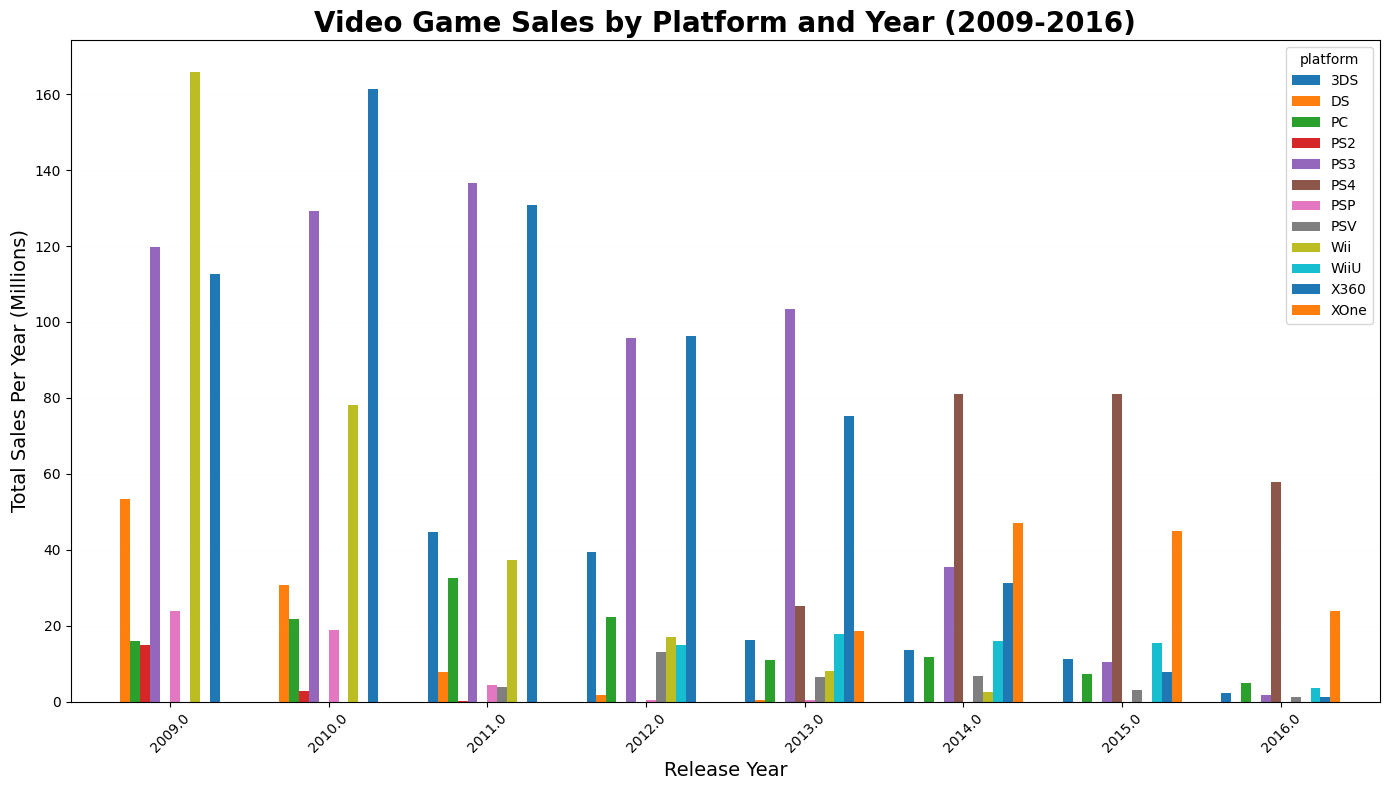

In [30]:

plt.figure(figsize=(14,8))

platform_sales_pivot.plot(kind='bar', figsize=(14,8), width=.75)

plt.title('Video Game Sales by Platform and Year (2009-2016)', fontsize=20, fontweight='bold')
plt.xlabel('Release Year', fontsize= 14)
plt.ylabel('Total Sales Per Year (Millions)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=.03)
plt.tight_layout()
plt.show()



<Figure size 1400x800 with 0 Axes>

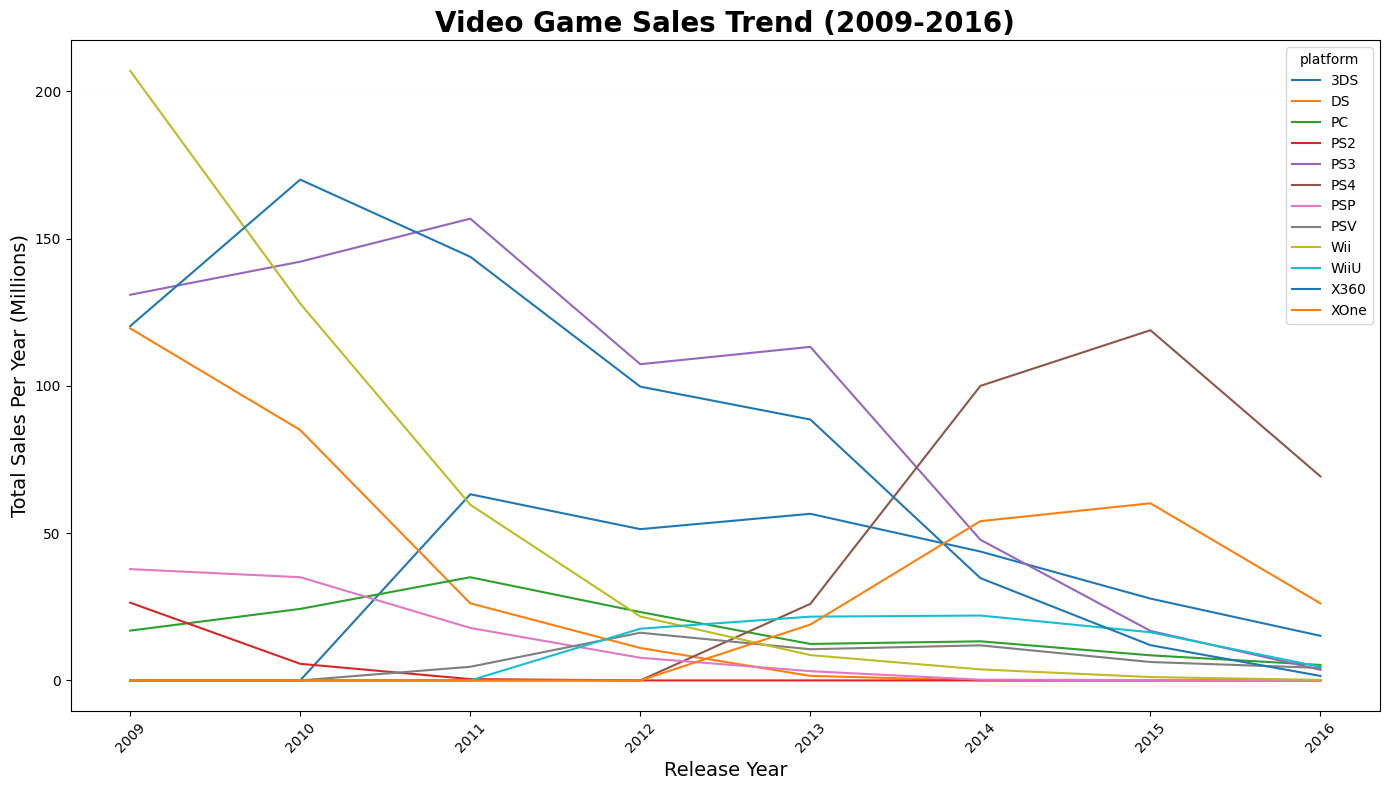

In [31]:
# Identify platforms with declining sales
recent_data['total_sales']= (recent_data['na_sales'] + recent_data['eu_sales'] + recent_data['jp_sales'] + recent_data['other_sales'])

platform_sales_pivot_complete=recent_data.pivot_table(values='total_sales', index='release_year', columns= 'platform', aggfunc='sum', fill_value=0)

plt.figure(figsize=(14,8))

platform_sales_pivot_complete.plot(kind='line', figsize=(14,8))

plt.title('Video Game Sales Trend (2009-2016)', fontsize=20, fontweight='bold')
plt.xlabel('Release Year', fontsize= 14)
plt.ylabel('Total Sales Per Year (Millions)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=.03)
plt.tight_layout()
plt.show()

As you can see in both of my plots every year most of the platforms have a decreased sale amount. There are obviously a few outliers each year but for the vast majority of them the sales revenue continues to show consistent decrease in sales. You can also see that several of the older generations of platforms either fell off substantially by 2011 or were completely obsolete. The obsolete platforms include the PS2 and DS. Those that dramatically fell off and were dangerously close to obsolecense are PSP and Wii. The most consistent of all the platforms looks to be PC, while it did not have the highest number of sales, it did stay fairly consistent across all years. Console platforms had much larger ebbs and flows to their markets than PC. Interestingly enough the Sony Platforms like PS3 and PS4 had the quickest rise and fall among all the platforms. Console lives seem to span short periods of time between 5-8 years depending on the platform. By the end of 2016 there are only a few platforms that seem to show consistent sales. The PS4, X360, and XOne appear to be the strongest performers going into 2017.  

### Questions to Consider:
- Which platforms show consistent sales over time?
- Can you identify platforms that have disappeared from the market?
- What's the typical lifecycle of a gaming platform?

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

I had already unknowningly done this earlier when I was cleaning my data. The reason I did it at that time was because of all of the missing data in the file. If I had filled the missing data in with averages or with medians it would have distorted the results of the actual data. I also was forward thinking about what kind of analysis that would need to be done on the data. If we are looking for the best way to focus our budget, it would require us to know the trends of recent years. Games and consoles that were relevent in the 1980s and 1990s were pioneers but they are not what people are focusing on today. People also view gaming differently in recent years in comparison to when they first came out. So it made sense to reduce the data pool down to the most relevent years. I decided that only using 2015 and 2016 would not have given me a large enough data pool to work with after scaling the data down to complete data sets and data sets only missing one of my 3 critical data points, critic score, user score, and rating. If 2 or more of those points were missing the data was scrapped. By doing this it gave me over 3000 usable lines of data that I could analyze. 

### Document Your Decision:
- What years did you select and why?
- How does this period reflect current market conditions?
- What factors influenced your decision?

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

<Figure size 1400x800 with 0 Axes>

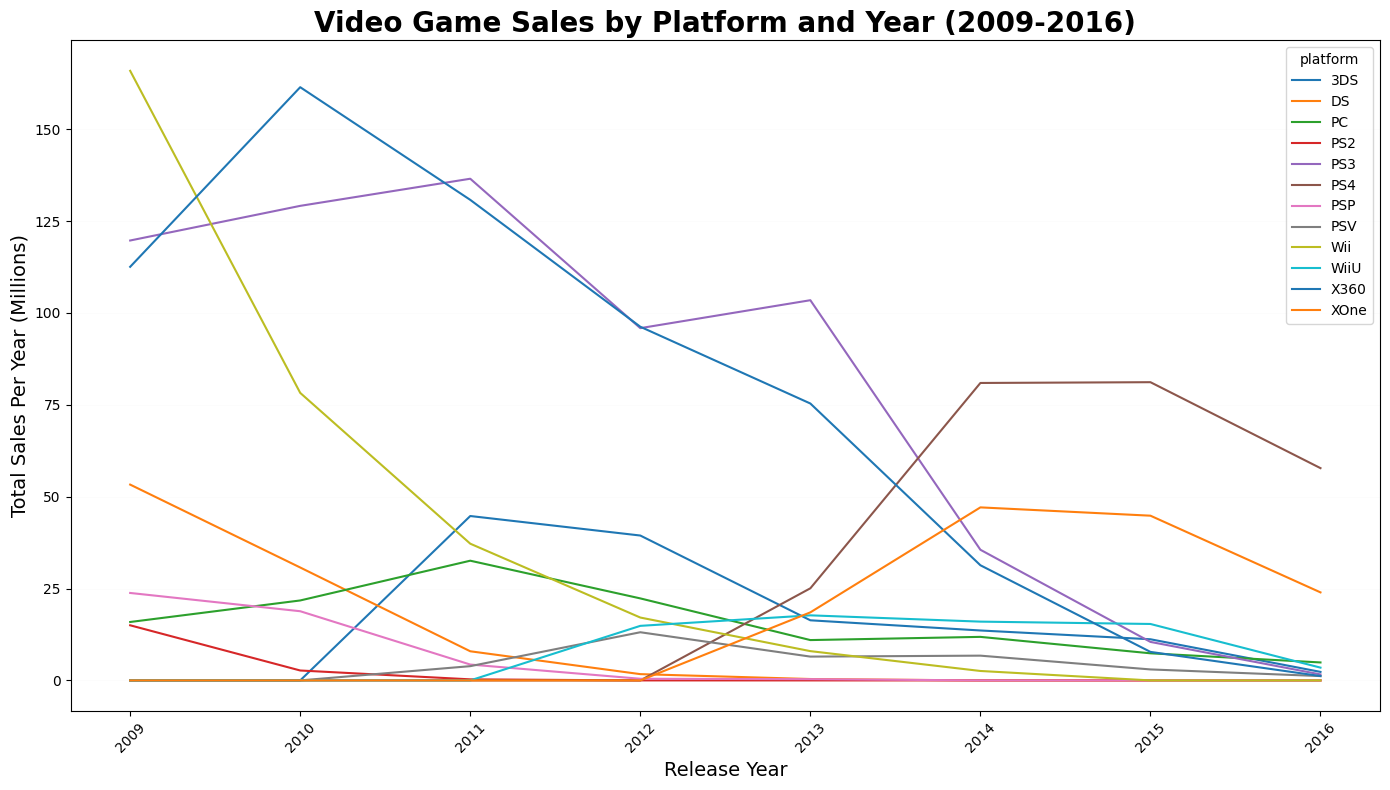

In [32]:
# Analyze platform sales trends
plt.figure(figsize=(14,8))

platform_sales_pivot.plot(kind='line', figsize=(14,8))

plt.title('Video Game Sales by Platform and Year (2009-2016)', fontsize=20, fontweight='bold')
plt.xlabel('Release Year', fontsize= 14)
plt.ylabel('Total Sales Per Year (Millions)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=.03)
plt.tight_layout()
plt.show()


In [33]:
# Sort platforms by total sales
platform_total_sales = clean_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(platform_total_sales)

platform
PS3     632.41
X360    616.68
Wii     309.01
PS4     244.95
XOne    134.40
PC      127.66
3DS     127.64
DS       94.04
WiiU     67.40
PSP      47.74
PSV      34.38
PS2      17.99
Name: total_sales, dtype: float64


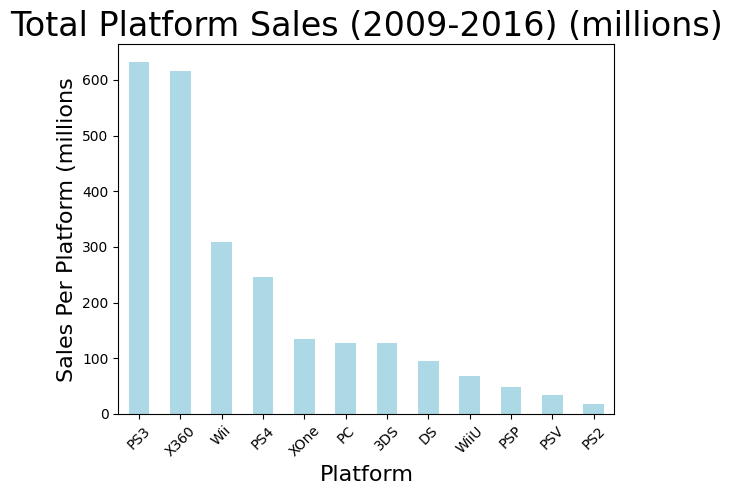

Year Over Year Growth (%):
    release_year platform  total_sales  yoy_pct_chg
14        2011.0      3DS        44.74         0.00
23        2012.0      3DS        39.43       -11.87
32        2013.0      3DS        16.36       -58.51
43        2014.0      3DS        13.59       -16.93
52        2015.0      3DS        11.20       -17.59
..           ...      ...          ...          ...
66        2016.0     X360         1.19       -84.66
42        2013.0     XOne        18.52         0.00
51        2014.0     XOne        47.09       154.27
59        2015.0     XOne        44.83        -4.80
67        2016.0     XOne        23.96       -46.55

[68 rows x 4 columns]


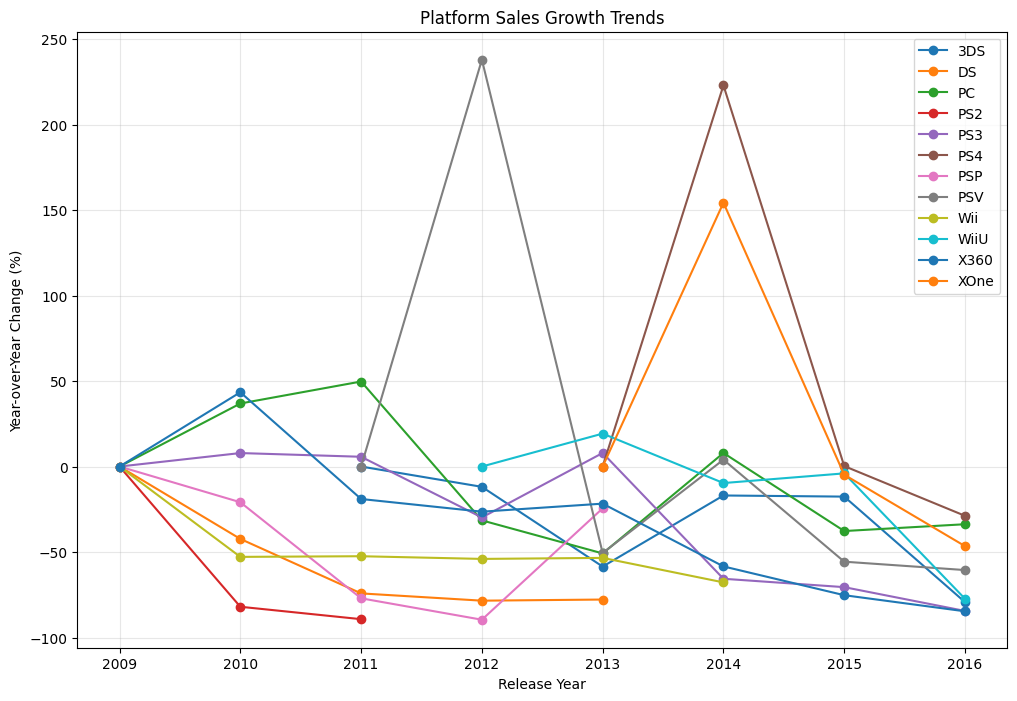

In [34]:
# Visualize top platforms
platform_total_sales.plot(kind='bar',color='lightblue')
plt.title('Total Platform Sales (2009-2016) (millions)', fontsize=24)
plt.xlabel('Platform',fontsize=16)
plt.ylabel('Sales Per Platform (millions',fontsize=16)
plt.xticks(rotation=45)
plt.show()


# Calculate year-over-year growth for each platform
platform_sales_2=clean_data.groupby(['release_year', 'platform'])['total_sales'].sum().reset_index()
platform_sales_2=platform_sales_2.sort_values(['platform', 'release_year'])
platform_sales_2['yoy_pct_chg']= platform_sales_2.groupby('platform')['total_sales'].pct_change()*100
platform_sales_2['yoy_pct_chg']=platform_sales_2['yoy_pct_chg'].fillna(0)
platform_sales_2=platform_sales_2.round(2)

print('Year Over Year Growth (%):')
print(platform_sales_2)
# Your code here to calculate and visualize platform growth rates
plt.figure(figsize=(12, 8))
for platform in platform_sales_2['platform'].unique():
    platform_data = platform_sales_2[platform_sales_2['platform'] == platform]
    plt.plot(platform_data['release_year'], platform_data['yoy_pct_chg'], 
             marker='o', label=platform)

plt.xlabel('Release Year')
plt.ylabel('Year-over-Year Change (%)')
plt.title('Platform Sales Growth Trends')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

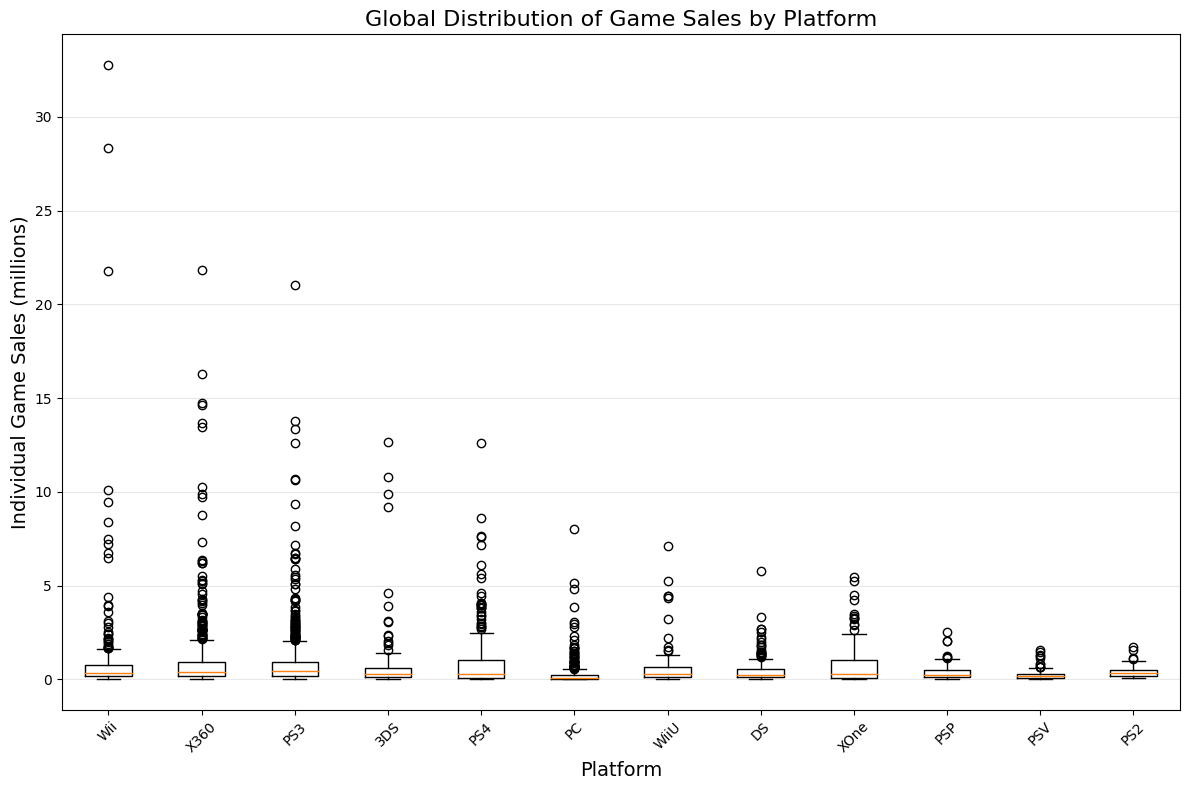

In [35]:
# Create box plot of sales by platform
plt.figure(figsize=(12, 8))
platform_data = []
platform_labels = []

for platform in clean_data['platform'].unique():
    platform_games = clean_data[clean_data['platform'] == platform]['total_sales']
    platform_data.append(platform_games)
    platform_labels.append(platform)

plt.boxplot(platform_data, labels=platform_labels)
plt.title('Global Distribution of Game Sales by Platform', fontsize=16)
plt.xlabel('Platform', fontsize=14)
plt.ylabel('Individual Game Sales (millions)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# Calculate detailed statistics for each platform
platform_stats=clean_data.groupby('platform')['total_sales'].describe()
print(platform_stats)

          count      mean       std   min   25%    50%     75%    max
platform                                                             
3DS       181.0  0.705193  1.643566  0.01  0.11  0.280  0.6200  12.65
DS        195.0  0.482256  0.678156  0.01  0.11  0.250  0.5350   5.80
PC        457.0  0.279344  0.648367  0.01  0.03  0.080  0.2400   8.01
PS2        41.0  0.438780  0.376113  0.06  0.18  0.350  0.5000   1.70
PS3       672.0  0.941086  1.707124  0.01  0.19  0.440  0.9400  21.05
PS4       258.0  0.949419  1.625742  0.01  0.07  0.260  1.0425  12.62
PSP       129.0  0.370078  0.399548  0.01  0.12  0.240  0.5000   2.54
PSV       143.0  0.240420  0.271827  0.01  0.08  0.160  0.3000   1.54
Wii       306.0  1.009837  2.991268  0.01  0.19  0.360  0.7600  32.77
WiiU      101.0  0.667327  1.159085  0.01  0.11  0.310  0.6400   7.09
X360      644.0  0.957578  1.926517  0.01  0.16  0.365  0.9400  21.82
XOne      184.0  0.730435  1.014874  0.01  0.08  0.285  1.0525   5.47


## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

I am choosing to analyze both the Xbox One and the PS4 data. This is because both are the newest platforms at this point with their consumer base growing each year while those with older platforms are beginning to lose consumers as they transition to the next generation of platform. The newer platforms while they have lower totals should give a better representation of what we should focus our efforts on. 

In [37]:
# Choose a popular platform based on your previous analysis
ps4_data= clean_data[clean_data['platform']=='PS4'].copy()
xone_data=clean_data[clean_data['platform']=='XOne'].copy()

print(f'PS4 games in data set:{len(ps4_data)}')
print(f'Xbox One games in data set:{len(xone_data)}')

PS4 games in data set:258
Xbox One games in data set:184


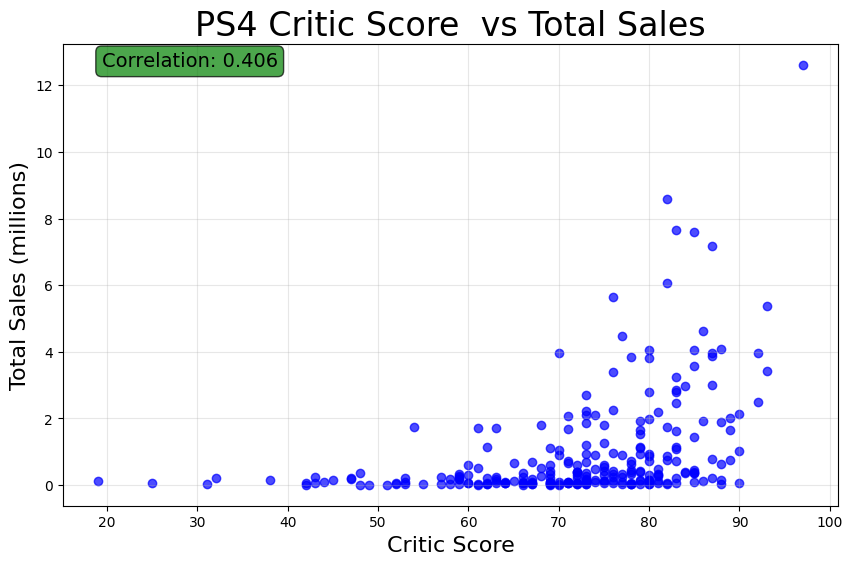

 PS4 -Critic Score Correlation: 0.406


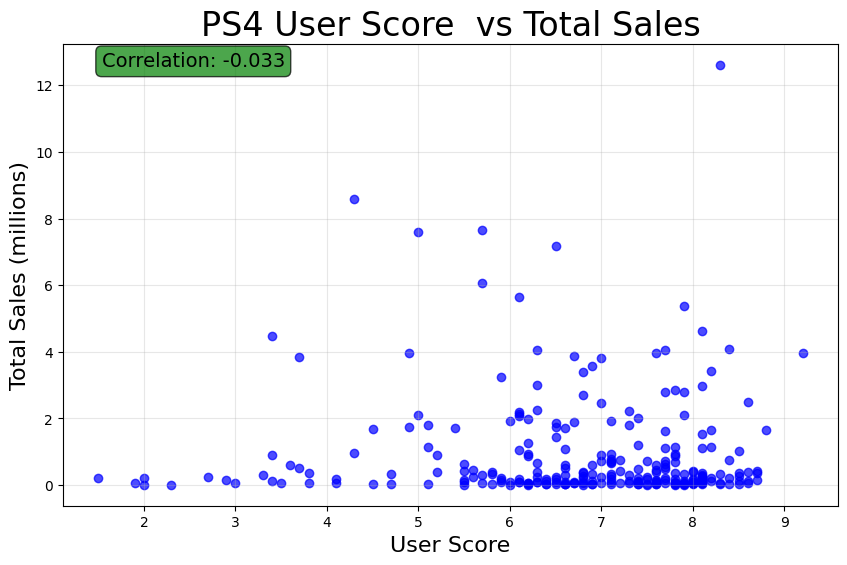

 PS4 -User Score Correlation: -0.033


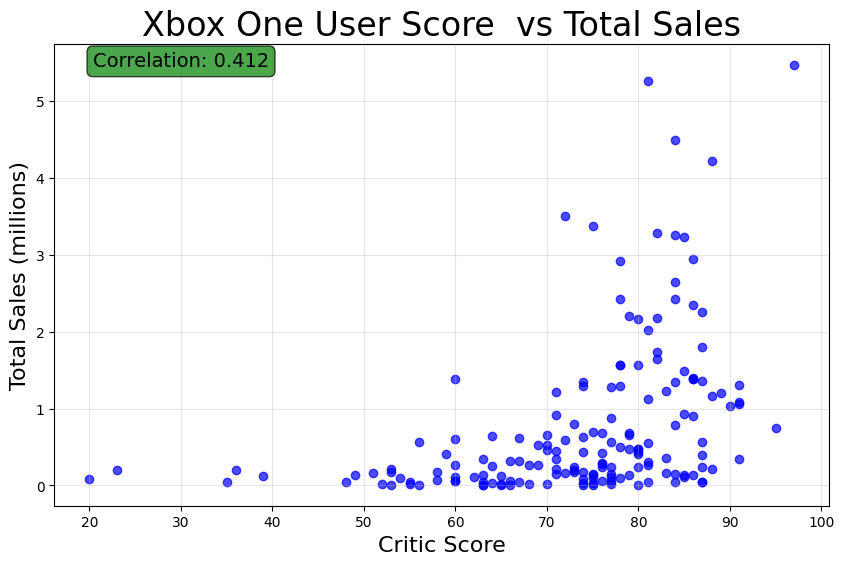

 Xbox One -Critic Score Correlation: 0.412


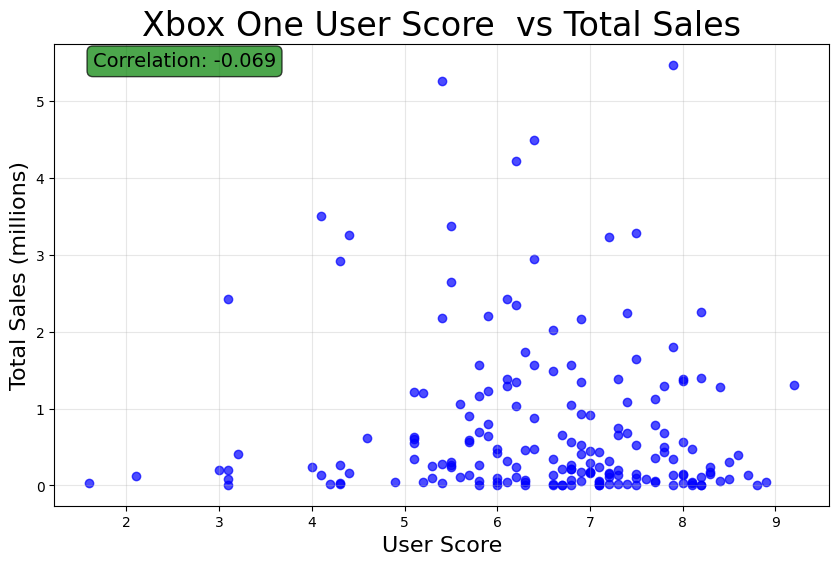

 Xbox One -User Score Correlation: -0.069


In [38]:
# Create scatter plots for both critic and user scores

plt.figure(figsize=(10,6))
plt.scatter(ps4_data['critic_score'], ps4_data['total_sales'], alpha=0.7, color='blue')
plt.title('PS4 Critic Score  vs Total Sales', fontsize=24)
plt.xlabel('Critic Score', fontsize=16)
plt.ylabel('Total Sales (millions)', fontsize=16)
plt.grid(True, alpha =0.3)

ps4_critic_corr= ps4_data['critic_score'].corr(ps4_data['total_sales'])
plt.text(0.05, 0.95, f'Correlation: {ps4_critic_corr:.3f}', 
         transform=plt.gca().transAxes, fontsize=14, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="green", alpha=0.7))
plt.show()
print(f' PS4 -Critic Score Correlation: {ps4_critic_corr:.3f}')


plt.figure(figsize=(10,6))
plt.scatter(ps4_data['user_score'], ps4_data['total_sales'], alpha=0.7, color='blue')
plt.title('PS4 User Score  vs Total Sales', fontsize=24)
plt.xlabel('User Score', fontsize=16)
plt.ylabel('Total Sales (millions)', fontsize=16)
plt.grid(True, alpha =0.3)

ps4_user_corr= ps4_data['user_score'].corr(ps4_data['total_sales'])
plt.text(0.05, 0.95, f'Correlation: {ps4_user_corr:.3f}', 
         transform=plt.gca().transAxes, fontsize=14, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="green", alpha=0.7))
plt.show()
print(f' PS4 -User Score Correlation: {ps4_user_corr:.3f}')



plt.figure(figsize=(10,6))
plt.scatter(xone_data['critic_score'], xone_data['total_sales'], alpha=0.7, color='blue')
plt.title('Xbox One User Score  vs Total Sales', fontsize=24)
plt.xlabel('Critic Score', fontsize=16)
plt.ylabel('Total Sales (millions)', fontsize=16)
plt.grid(True, alpha =0.3)

xone_critic_corr= xone_data['critic_score'].corr(xone_data['total_sales'])
plt.text(0.05, 0.95, f'Correlation: {xone_critic_corr:.3f}', 
         transform=plt.gca().transAxes, fontsize=14, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="green", alpha=0.7))
plt.show()
print(f' Xbox One -Critic Score Correlation: {xone_critic_corr:.3f}')



plt.figure(figsize=(10,6))
plt.scatter(xone_data['user_score'], xone_data['total_sales'], alpha=0.7, color='blue')
plt.title('Xbox One User Score  vs Total Sales', fontsize=24)
plt.xlabel('User Score', fontsize=16)
plt.ylabel('Total Sales (millions)', fontsize=16)
plt.grid(True, alpha =0.3)

xone_user_corr= xone_data['user_score'].corr(xone_data['total_sales'])
plt.text(0.05, 0.95, f'Correlation: {xone_user_corr:.3f}', 
         transform=plt.gca().transAxes, fontsize=14, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="green", alpha=0.7))
plt.show()
print(f' Xbox One -User Score Correlation: {xone_user_corr:.3f}')


In [39]:
#for clarity and readability here are the scores seperated from the plots. 
print(f' PS4 -Critic Score Correlation: {ps4_critic_corr:.3f}')
print()
print(f' PS4 -User Score Correlation: {ps4_user_corr:.3f}')
print()
print(f' Xbox One -Critic Score Correlation: {xone_critic_corr:.3f}')
print()
print(f' Xbox One -Critic Score Correlation: {xone_user_corr:.3f}')



 PS4 -Critic Score Correlation: 0.406

 PS4 -User Score Correlation: -0.033

 Xbox One -Critic Score Correlation: 0.412

 Xbox One -Critic Score Correlation: -0.069


## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [40]:
# Find games released on multiple platforms
multi_platform_games=clean_data.groupby('name').filter(lambda x: x['platform'].nunique()>1)
print(f"Games Released on Multiple Platforms: {multi_platform_games['name'].nunique()}")


Games Released on Multiple Platforms: 761


In [41]:
# Compare sales across platforms for these games

cross_platform_sales = (multi_platform_games.groupby(['name', 'platform'])['total_sales'].sum().unstack().dropna(how='all'))
cross_platform_sales['total_across_platforms'] = cross_platform_sales.sum(axis=1)
cross_platform_sales = cross_platform_sales.sort_values(by='total_across_platforms', ascending=False)
print(cross_platform_sales.head(10))
# Your code here to analyze and visualize cross-platform performance

platform                         3DS    DS    PC  PS2    PS3    PS4  PSP  PSV  \
name                                                                            
Grand Theft Auto V               NaN   NaN  1.17  NaN  21.05  12.62  NaN  NaN   
Call of Duty: Modern Warfare 3   NaN   NaN  1.71  NaN  13.33    NaN  NaN  NaN   
Call of Duty: Black Ops II       NaN   NaN  1.52  NaN  13.79    NaN  NaN  NaN   
Call of Duty: Black Ops          NaN  0.58   NaN  NaN  12.63    NaN  NaN  NaN   
Call of Duty: Ghosts             NaN   NaN   NaN  NaN   9.36   3.83  NaN  NaN   
Call of Duty: Modern Warfare 2   NaN   NaN  0.89  NaN  10.61    NaN  NaN  NaN   
Call of Duty: Advanced Warfare   NaN   NaN  0.41  NaN   4.36   7.66  NaN  NaN   
The Elder Scrolls V: Skyrim      NaN   NaN  3.88  NaN   6.40    NaN  NaN  NaN   
FIFA 15                         0.46   NaN  0.29  NaN   4.28   6.08  NaN  0.6   
Battlefield 3                    NaN   NaN  2.78  NaN   7.17    NaN  NaN  NaN   

platform                   

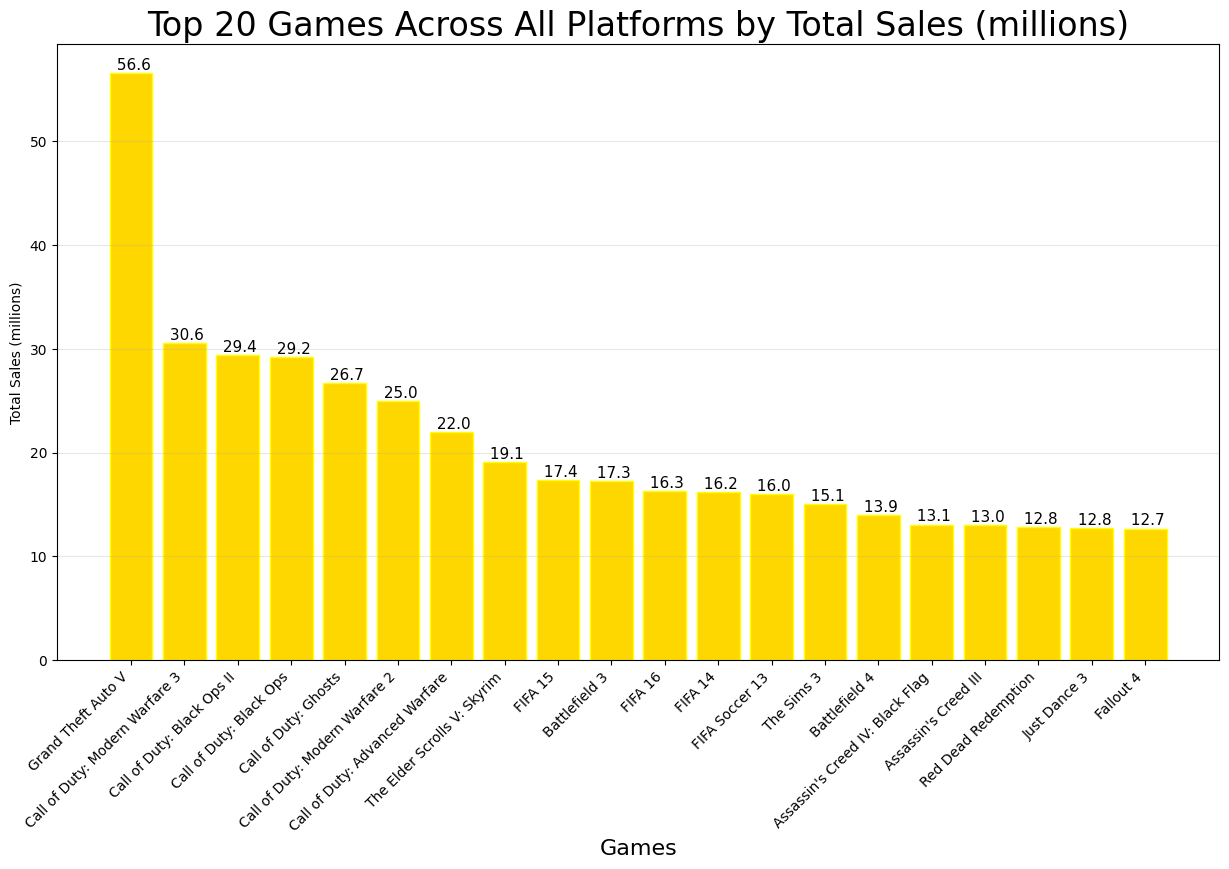

In [42]:
top_20_cross_platform=cross_platform_sales.head(20)

plt.figure(figsize=(15,8))
plt.bar(range(len(top_20_cross_platform)), top_20_cross_platform['total_across_platforms'], color= 'gold', edgecolor= 'yellow', linewidth=1)

plt.title('Top 20 Games Across All Platforms by Total Sales (millions)',fontsize=24)
plt.xlabel('Games', fontsize=16)
plt.ylabel('Total Sales (millions)')
plt.xticks(range(len(top_20_cross_platform)), top_20_cross_platform.index, rotation=45, ha='right')

for i, v in enumerate(top_20_cross_platform['total_across_platforms']):
    plt.text(i, v + .05, f' {v:.1f}', ha='center', va='bottom', fontsize=11)
plt.grid(axis='y', alpha=.3)
plt.show()

## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [43]:
# Analyze genre performance
genre_stats=clean_data.groupby('genre').agg({'total_sales': ['count','sum', 'mean', 'median'], 'critic_score': 'mean', 'user_score':'mean'}).round(2)
genre_stats.columns= ['num_games', 'total_sales', 'avg_sales', 'median_sales', 'avg_critic', 'avg_user']
print(genre_stats)

              num_games  total_sales  avg_sales  median_sales  avg_critic  \
genre                                                                       
Action              988       654.56       0.66          0.27       68.08   
Adventure           158        40.56       0.26          0.10       67.04   
Fighting            167        90.40       0.54          0.34       70.34   
Misc                227       191.91       0.85          0.37       69.33   
Platform            129       139.69       1.08          0.24       73.13   
Puzzle               59        25.94       0.44          0.14       69.56   
Racing              192       122.01       0.64          0.22       70.29   
Role-Playing        325       216.28       0.67          0.26       72.69   
Shooter             400       492.09       1.23          0.44       71.15   
Simulation          122        62.42       0.51          0.20       64.94   
Sports              431       382.59       0.89          0.40       70.88   

In [44]:
# Sort genres by total sales
genre_stats=genre_stats.sort_values('total_sales', ascending= False)
print(genre_stats)

              num_games  total_sales  avg_sales  median_sales  avg_critic  \
genre                                                                       
Action              988       654.56       0.66          0.27       68.08   
Shooter             400       492.09       1.23          0.44       71.15   
Sports              431       382.59       0.89          0.40       70.88   
Role-Playing        325       216.28       0.67          0.26       72.69   
Misc                227       191.91       0.85          0.37       69.33   
Platform            129       139.69       1.08          0.24       73.13   
Racing              192       122.01       0.64          0.22       70.29   
Fighting            167        90.40       0.54          0.34       70.34   
Simulation          122        62.42       0.51          0.20       64.94   
Adventure           158        40.56       0.26          0.10       67.04   
Strategy            113        35.85       0.32          0.12       72.53   

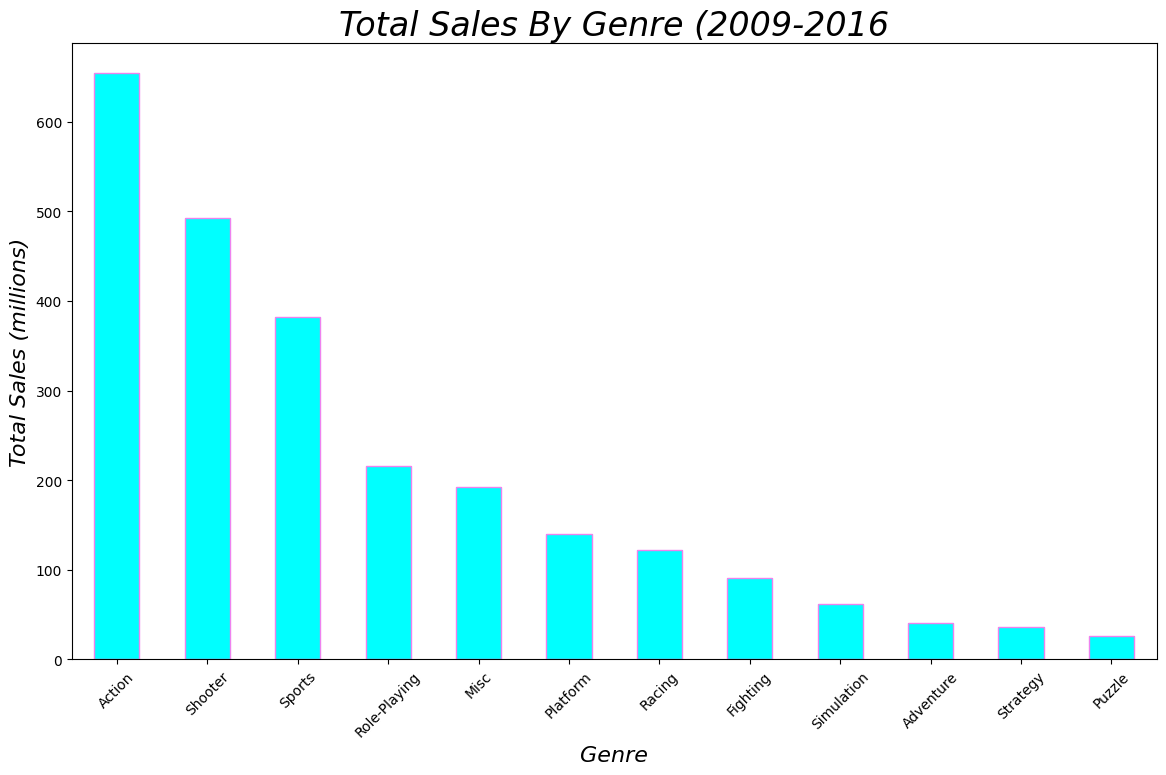

In [45]:
# Visualize genre distribution
plt.figure(figsize=(14,8))
genre_stats['total_sales'].plot(kind='bar', color='aqua', edgecolor='violet')
plt.title('Total Sales By Genre (2009-2016', fontsize=24, style='italic')
plt.xlabel('Genre', fontsize=16, style='italic')
plt.ylabel('Total Sales (millions)', fontsize=16, style='italic')
plt.xticks(rotation=45)
plt.show()

In [46]:
# Calculate market share for each genre
genre_market_share = clean_data.groupby('genre')['total_sales'].sum().reset_index()

total_sales_all = genre_market_share['total_sales'].sum()
genre_market_share['market_share_%'] = (genre_market_share['total_sales'] / total_sales_all * 100).round(2)

genre_market_share = genre_market_share.sort_values('market_share_%', ascending=False)

print("=== Market Share for Each Genre (2009-2016) ===")
print(genre_market_share[['genre', 'total_sales', 'market_share_%']])

=== Market Share for Each Genre (2009-2016) ===
           genre  total_sales  market_share_%
0         Action       654.56           26.67
8        Shooter       492.09           20.05
10        Sports       382.59           15.59
7   Role-Playing       216.28            8.81
3           Misc       191.91            7.82
4       Platform       139.69            5.69
6         Racing       122.01            4.97
2       Fighting        90.40            3.68
9     Simulation        62.42            2.54
1      Adventure        40.56            1.65
11      Strategy        35.85            1.46
5         Puzzle        25.94            1.06


When reviewing the data, it appears that the 3 best performing genres are Action, Shooter, and Sports. I would venture to say this is likely due to online play with these genres. Online play is a large component to gaming. All platforms have shown decline since 2009. However in 2014 you see major spikes in PS4 and Xbox One sales. This is because this is really the first full year they are in the market. Both Platforms launched in late 2013 just before the holidays, with limited stock availability they were lower than 2014. 2015 and 2016 both showed continued decline for both of the new Platforms. In reviewing the averages per genre it does not appear that any one genre does substantially better than another. They generally all range between 6.5 and 7.2 in user score and 68 to 73 in critic score. However when looking at the difference between Critic score and User score, there tends to be a fairly large gap between them. To keep it simple we will use a scale of 0-100. In the top 3 categories, action, shooter, and sports there is at minimum a 5% difference where the User score is lower than Critic score. Where as roleplaying, adventure, and puzzle seem to generally fall in the same range closer to 1-2% difference between the scores. It also to me does not appear to show any impact on reviews to the total number of games sold. If anything it would seem that the genres that have the most games in them are the ones that generate the most revenue.  

### Key Questions for Genre Analysis:
- Which genres consistently perform well?
- Are there any genres showing recent growth or decline?
- How does the average performance vary across genres?

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [47]:
# Function to analyze platform performance by region
region_sales=clean_data.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()
region_sales['total_sales']= region_sales.sum(axis=1)
region_sales=region_sales.sort_values('total_sales', ascending=False)

print(' Sales by Region for Each Platform')
print(region_sales.round(2))

 Sales by Region for Each Platform
          na_sales  eu_sales  jp_sales  other_sales  total_sales
platform                                                        
PS3         265.89    225.22     49.11        92.19       632.41
X360        378.40    178.91      5.76        53.61       616.68
Wii         164.74     94.32     23.50        26.45       309.01
PS4          84.68    112.78      9.45        38.04       244.95
XOne         78.67     43.41      0.29        12.03       134.40
PC           37.60     75.16      0.00        14.90       127.66
3DS          50.54     35.03     34.11         7.96       127.64
DS           47.14     23.75     16.01         7.14        94.04
WiiU         31.28     21.04     10.17         4.91        67.40
PSP          15.99     14.12      9.31         8.32        47.74
PSV          10.45     10.30      8.52         5.11        34.38
PS2           6.70      3.30      0.24         7.75        17.99


What is interesting about this data is it seems that on the newer platforms the eu_sales seem to be higher than na_sales. Where as on platforms that have been out for longer those are distinctly higher sales in na_sales compared to everywhere else. 


### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [48]:
# Create a comparative platform analysis
# Analyze each region
regional_sales_stats=clean_data.groupby('platform').agg({'na_sales': ['sum', 'mean'], 'eu_sales': ['sum', 'mean'], 'jp_sales': ['sum', 'mean'], 'other_sales': ['sum', 'mean'], 'total_sales': 'mean', 'critic_score': 'mean', 'user_score': 'mean', 'name': 'count'}).round(2)

regional_sales_stats = regional_sales_stats.sort_values(('total_sales', 'mean'), ascending=False)

print('Regional Sales Statistics Including Average Scores by Platform')
print(regional_sales_stats)


Regional Sales Statistics Including Average Scores by Platform
         na_sales       eu_sales       jp_sales       other_sales        \
              sum  mean      sum  mean      sum  mean         sum  mean   
platform                                                                  
Wii        164.74  0.54    94.32  0.31    23.50  0.08       26.45  0.09   
X360       378.40  0.59   178.91  0.28     5.76  0.01       53.61  0.08   
PS4         84.68  0.33   112.78  0.44     9.45  0.04       38.04  0.15   
PS3        265.89  0.40   225.22  0.34    49.11  0.07       92.19  0.14   
XOne        78.67  0.43    43.41  0.24     0.29  0.00       12.03  0.07   
3DS         50.54  0.28    35.03  0.19    34.11  0.19        7.96  0.04   
WiiU        31.28  0.31    21.04  0.21    10.17  0.10        4.91  0.05   
DS          47.14  0.24    23.75  0.12    16.01  0.08        7.14  0.04   
PS2          6.70  0.16     3.30  0.08     0.24  0.01        7.75  0.19   
PSP         15.99  0.12    14.12  0.1

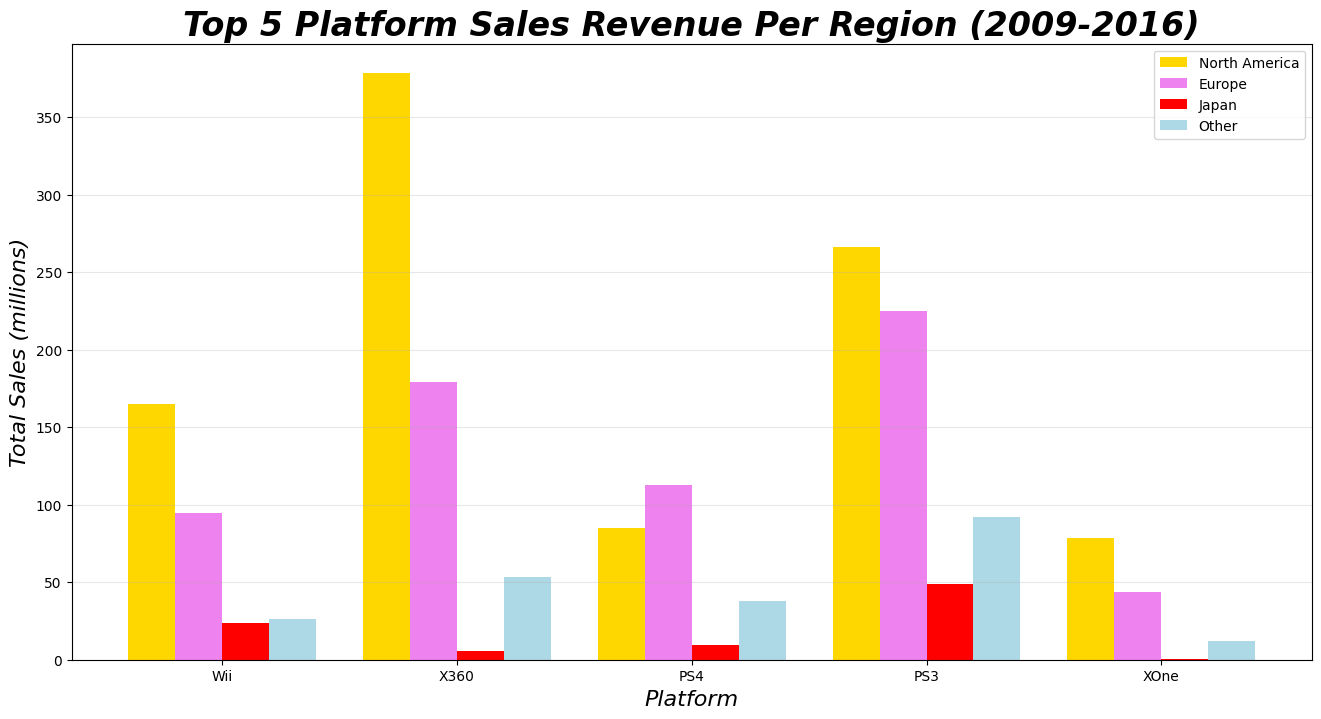

In [49]:
# Visualize cross-regional comparison for top platforms
top_platforms = regional_sales_stats.head(5)

plt.figure(figsize=(16, 8))

na_sales = top_platforms[('na_sales', 'sum')]
eu_sales = top_platforms[('eu_sales', 'sum')]
jp_sales = top_platforms[('jp_sales', 'sum')]
other_sales = top_platforms[('other_sales', 'sum')]

platforms = top_platforms.index
bar_width = 0.2
x_pos = range(len(platforms))

plt.bar([x - 1.5*bar_width for x in x_pos], na_sales, bar_width, label='North America', color='gold')
plt.bar([x - 0.5*bar_width for x in x_pos], eu_sales, bar_width, label='Europe', color='violet')
plt.bar([x + 0.5*bar_width for x in x_pos], jp_sales, bar_width, label='Japan', color='red')
plt.bar([x + 1.5*bar_width for x in x_pos], other_sales, bar_width, label='Other', color='lightblue')

plt.title('Top 5 Platform Sales Revenue Per Region (2009-2016)', fontsize=24, style='italic', fontweight='bold')
plt.xlabel('Platform', fontsize=16, style='italic')
plt.ylabel('Total Sales (millions)', fontsize=16, style='italic')
plt.xticks(x_pos, platforms)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()



## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [50]:
# Function to analyze genre performance by region
genre_per_region=clean_data.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales']].sum()

### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

<Figure size 1500x800 with 0 Axes>

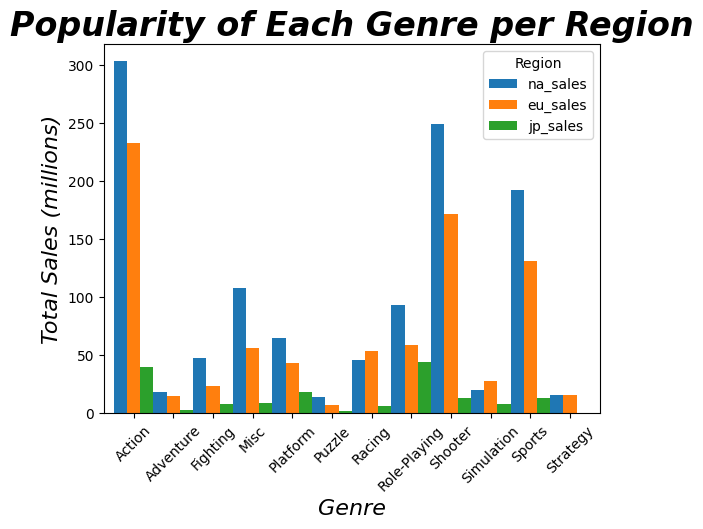

In [51]:
# Create a comparative genre analysis
plt.figure(figsize=(15,8))
genre_per_region.plot(kind='bar', width=1)
plt.title('Popularity of Each Genre per Region', fontsize=24, fontweight='bold', style='italic')
plt.ylabel('Total Sales (millions)', fontsize=16, style='italic')
plt.xlabel('Genre', fontsize=16, style='italic')
plt.xticks(rotation=45)
plt.legend(title= 'Region')
plt.show()

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [52]:
# Function to analyze ESRB rating impact
rating_sales=clean_data.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].mean().round(2)

In [53]:
# Analyze ESRB impact for each region
print(rating_sales)

        na_sales  eu_sales  jp_sales  other_sales  total_sales
rating                                                        
E           0.41      0.30      0.08         0.09         0.89
E10+        0.29      0.18      0.03         0.06         0.56
M           0.53      0.39      0.04         0.13         1.10
RP          0.00      0.03      0.00         0.01         0.04
T           0.22      0.15      0.05         0.06         0.48


# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


In [54]:
from scipy import stats

#Hypothesis 1 Average Ratings Of Xbox One and PC platforms are the same
xone=clean_data[clean_data['platform']=='XOne']['user_score'].dropna()
pc=clean_data[clean_data['platform']=='PC']['user_score'].dropna()
t_stat, p_value=stats.ttest_ind(xone,pc)

print( 'H1: Xbox One VS PC User Scores')
print(f'p-value: {p_value:.4f}')
print('Conclusion: Reject HO' if p_value < .05 else 'Conclusion: Fail to reject HO')


H1: Xbox One VS PC User Scores
p-value: 0.3177
Conclusion: Fail to reject HO


Null Hypothesis (H0): The average user ratings of the Xbox One and PC platforms are the same. 

Alternative Hypothesis (H1): The average user ratings of the Xbox One and PC platforms are different. 
Alpha Level: .05 this is the standard threshold used in statistical testing. We can accept a 5% chance of incorrectly rejecting the null hypothesis. 

Test used : A two-sided independent samples t-test. I did this because we are comparing the means of two independent groups. Xbox One and PC users. We have no reason to believe one platform would score higher than the other, making the two-sided the right choice. 

The result with a p-value of .3117, which is greater than our alpha of .05, we fail to reject the null hypothesis. This means there is not enough statistical evidence to conclude that Xbox One and PC Users rate games any differently than each other. This means we should not use these points to decide which platform would be best for our budget. 

In [55]:


#Hypothesis 2: Average User ratings for Action and Sports are different
action=clean_data[clean_data['genre']=='Action']['user_score'].dropna()
sports=clean_data[clean_data['genre']=='Sports']['user_score'].dropna()
t_stat2, p_value2= stats.ttest_ind(action, sports)
print('H2: Action Vs Sports User Scores')
print(f't-statistic:{t_stat2:.4f}')
print(f'p-value:{p_value2:.4f}')
print('Conclusion: Reject HO' if p_value2< .05 else 'Conclusion: Fail to reject HO')




H2: Action Vs Sports User Scores
t-statistic:8.0719
p-value:0.0000
Conclusion: Reject HO


Null Hypothesis(H0): The average user ratings for Action and Sports genres are the same. 

Alternative Hypothesis (H2): The average user ratings for Action and Sports genres are different. 

Alpha level: .05 as with the first test this is the standard 5% significance threshold. 

Test: A two-sided independnt samples t-test. As with the first test we used this one as we are testing the means of two independent groups. Actions and Sports users and we are testing whether there is a difference between the two in either direction. 

The result with a p-value of 0.00 which is less than our alpha of .05 we reject the null hypothesis. This is because there is strong statistical evidence suggesting that Action and Sports genre games are rated differently by users. This could influence which genre we should focus our budget on due to the clear difference between the genres ratings. 

# Step 6. Write a general conclusion


Conclusion
Platform Strategy: PS4 and Xbox One are the current generation leaders and show strong potential. PS4 had the highest total sales between the newer platforms.
Genres: Of the 12 genres the 3 that performed the best were Action, Shooter, and Sports. All 3 were significantly higher in generated sales revenues compared to the others. When deciding what genres we should focus on these 3 would be at the top of the list. 
Reviews: Critic reviews may have some impact on revenues as they had a slightly positive correlation to sales revenue, where as user reviews had a negative correlation. I believe this is because critic reviews are generally looked at before purchase and user reviews are usually based on after games have been purchased and played. If we are to use reviews definitely focus on critic positive reviews. 
Regional Differences: North America and Europe are the clear leaders in total overall sales purchases. with Action and Shooter games being the largest genres in each. Japan however prefers to play role playing games.
Market Trends: Overall sales per platform decline as generations age. Newer generation platforms have already seen steep declines in platform sales. 

My recommendation for 2017 marketing budget would be for platform focus to be on PS4 and Xbox one. With regional marketing campaigns based on what is most often purchased in each region. Action, Sports, and Shooters for the NA and EU markets, while changing to a Role playing focus in Japan. 